# Depot vs. Private Insurance

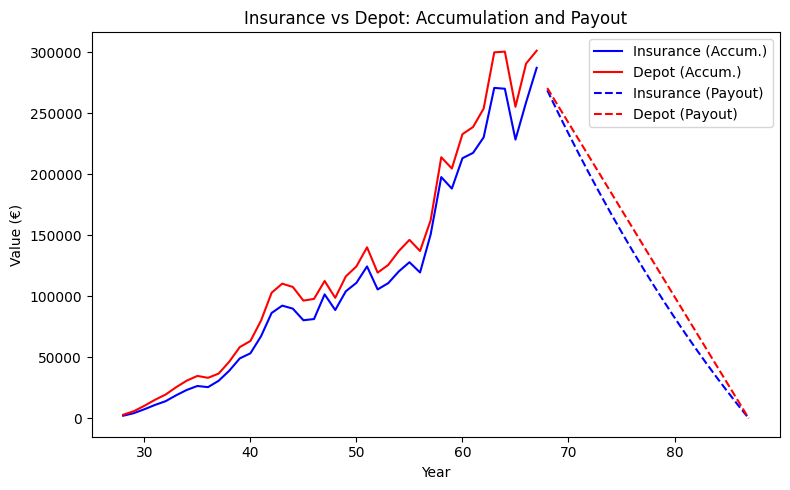

Insurance leftover after payout: 0.00 €
Depot leftover after payout:     0.00 €


In [ ]:
import matplotlib.pyplot as plt
import random


# --- FIFO helper functions for the depot ---
def add_depot_lot(lots, amount):
    # Each new deposit becomes a separate lot.
    lots.append({"value": amount, "basis": amount})
    return lots


def apply_growth(lots, sampled_return):
    # Update the market value of each lot using the same sampled return
    for lot in lots:
        lot["value"] *= 1 + sampled_return
    return lots


def total_depot_value(lots):
    return sum(lot["value"] for lot in lots)


def total_cost_basis(lots):
    return sum(lot["basis"] for lot in lots)


def rebalance_depot_fifo(lots, rebalancing_ratio, depot_tax_rate):
    """
    Sells enough from the oldest lots (FIFO) so that a fraction 'rebalancing_ratio' of
    the total depot value is sold. Taxes are calculated on the gain of each sold part.
    The net proceeds are then reinvested as a new lot (with its basis set to the net proceeds).
    """
    total_value = total_depot_value(lots)
    target_sell = total_value * rebalancing_ratio
    sold = 0.0
    tax_total = 0.0

    # Sell from the oldest lots first
    while lots and sold < target_sell:
        lot = lots[0]
        if sold + lot["value"] <= target_sell:
            # Sell the entire lot.
            sold += lot["value"]
            gain = lot["value"] - lot["basis"]
            tax = gain * depot_tax_rate if gain > 0 else 0.0
            tax_total += tax
            lots.pop(0)
        else:
            # Sell a fraction of this lot.
            remaining_to_sell = target_sell - sold
            ratio = remaining_to_sell / lot["value"]
            sold += remaining_to_sell
            sold_basis = lot["basis"] * ratio
            gain = remaining_to_sell - sold_basis
            tax = gain * depot_tax_rate if gain > 0 else 0.0
            tax_total += tax
            # Adjust the current lot: subtract the sold portion from both value and basis.
            lot["value"] -= remaining_to_sell
            lot["basis"] -= sold_basis
            break
    # Reinvest the sold proceeds net of tax as a new lot.
    reinvested = target_sell - tax_total
    if reinvested > 0:
        lots.append({"value": reinvested, "basis": reinvested})
    return lots


# --- Main simulation functions ---
def simulate_insurance_vs_depot(
    monthly_investment,  # € per month
    accumulation_years,
    annual_return,  # e.g., 7.5% p.a.
    volatility,  # Standard deviation for annual return sampling
    rebalancing_interval,  # in years (e.g., every 10)
    rebalancing_ratio,  # fraction of depot to rebalance (e.g., 10%)
    depot_tax_rate,  # e.g., 25% capital gains tax for depot
    insurance_fixed_cost,  # € per year
    insurance_abschluss_cost,  # € per year, first `abschluss_years` years
    abschluss_years,  # e.g., 5 years
    insurance_asset_fee,  # e.g., 0.0048 (0.48% p.a.)
):
    """
    Accumulates money in both an insurance product and a depot.
    Returns yearly pot values (lists) plus the final cost basis for the depot.
    """
    # Tracking arrays for plotting
    insurance_vals = []
    depot_vals = []

    # Insurance
    value_ins = 0.0
    total_paid_ins = 0.0

    # Depot (using FIFO lots)
    depot_lots = []  # List of dicts: each with 'value' and 'basis'
    total_paid_depot = 0.0

    # Accumulation phase
    for year in range(1, accumulation_years + 1):
        annual_investment = monthly_investment * 12

        # Sample one annual return for this year (applied uniformly)
        sampled_return = random.normalvariate(annual_return, volatility)

        # --- Insurance ---
        total_paid_ins += annual_investment
        value_ins += annual_investment

        # Costs for insurance
        value_ins -= insurance_fixed_cost
        if year <= abschluss_years:
            value_ins -= insurance_abschluss_cost

        # Asset fee
        value_ins *= 1 - insurance_asset_fee

        # Growth for insurance with fluctuation
        value_ins *= 1 + sampled_return

        # --- Depot (using FIFO lots) ---
        total_paid_depot += annual_investment
        add_depot_lot(depot_lots, annual_investment)

        # Apply the same annual growth to all lots
        apply_growth(depot_lots, sampled_return)

        # Rebalancing necessary?
        if year % rebalancing_interval == 0:
            depot_lots = rebalance_depot_fifo(depot_lots, rebalancing_ratio, depot_tax_rate)

        # Compute overall depot value and cost basis for plotting and later taxation.
        value_depot = total_depot_value(depot_lots)
        cost_basis_depot = total_cost_basis(depot_lots)

        # Store for plotting
        insurance_vals.append(value_ins)
        depot_vals.append(value_depot)

    return (
        insurance_vals,
        depot_vals,
        value_ins,
        value_depot,
        cost_basis_depot,
        total_paid_ins,
        total_paid_depot,
    )


def simulate_payout_phase(
    insurance_start,
    depot_start,
    cost_basis_depot,
    payout_years=20,
    insurance_payout_tax=0.10,
    insurance_payout_fee=0.015,  # 1.5% annual cost on pot
    depot_tax_rate=0.25,
):
    """
    Simulates a payout phase over `payout_years`:
      - Depot: pays a lump-sum tax upfront on untaxed gains (depot_start - cost_basis_depot),
        then withdraws equal fractions each year. During this withdrawal phase,
        money is on a bank account, no further growth, no further taxes.
      - Insurance: each year, deducts a fee from the pot, then withdraws a fraction, taxed at ~10%.
    Returns:
      insurance_vals: list of insurance pot values over the payout period.
      depot_vals: list of depot pot values over the payout period.
      total_net_payout_ins: total net cash received from insurance over the payout phase.
      total_net_payout_dep: total net cash received from depot over the payout phase.
      final_ins_value: final leftover in the insurance pot.
      final_dep_value: final leftover in the depot pot.
    """
    insurance_vals = []
    depot_vals = []

    total_net_payout_ins = 0.0  # Total net cash received from insurance
    total_net_payout_dep = 0.0  # Total cash received from depot

    # For depot, adjust for upfront tax on untaxed gains:
    untaxed_gain = depot_start - cost_basis_depot
    if untaxed_gain > 0:
        depot_start -= untaxed_gain * depot_tax_rate

    value_depot = depot_start
    value_ins = insurance_start

    for year in range(1, payout_years + 1):
        # ============ INSURANCE Payout ============
        # Deduct annual fee from the insurance pot
        value_ins *= 1 - insurance_payout_fee

        # Withdraw an equal fraction for this year
        payout_ins = value_ins / (payout_years - year + 1)
        # Tax the withdrawal at 10%
        tax_ins = payout_ins * insurance_payout_tax
        net_payout_ins = payout_ins - tax_ins

        total_net_payout_ins += net_payout_ins
        value_ins -= payout_ins

        # ============ DEPOT Payout ============
        # For depot, withdraw an equal fraction (no additional tax, because it's already paid)
        payout_dep = value_depot / (payout_years - year + 1)
        total_net_payout_dep += payout_dep
        value_depot -= payout_dep

        insurance_vals.append(value_ins)
        depot_vals.append(value_depot)

    return (
        insurance_vals,
        depot_vals,
        total_net_payout_ins,
        total_net_payout_dep,
        value_ins,
        value_depot,
    )


def plot_results(curr_age, accum_years, payout_years, ins_accum, dep_accum, ins_payout, dep_payout):
    """
    Plots insurance vs depot pot values over time (accumulation + payout).
    """
    plt.figure(figsize=(8, 5))

    # Build x-axis
    x_accum = range(curr_age + 1, curr_age + accum_years + 1)
    x_payout = range(curr_age + accum_years + 1, curr_age + accum_years + payout_years + 1)

    # Plot accumulation
    plt.plot(x_accum, ins_accum, label="Insurance (Accum.)", color="blue")
    plt.plot(x_accum, dep_accum, label="Depot (Accum.)", color="red")

    # Plot payout
    plt.plot(x_payout, ins_payout, label="Insurance (Payout)", color="blue", linestyle="--")
    plt.plot(x_payout, dep_payout, label="Depot (Payout)", color="red", linestyle="--")

    plt.title("Insurance vs Depot: Accumulation and Payout")
    plt.xlabel("Year")
    plt.ylabel("Value (€)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------
# Main simulation execution
# --------------------------
# Current age
curr_age = 27

# Depot tax rate
depot_tax_rate = 0.25  # 25% capital gains tax for depot

# Insurance payout tax
insurance_payout_tax = 0.10  # ~10% on insurance gains

# 1) Accumulate
accum_years = 40
volatility = 0.15  # Standard deviation for annual returns (MSCI World)

ins_vals, dep_vals, final_ins, final_dep, cb_depot, total_ins_paid, total_dep_paid = (
    simulate_insurance_vs_depot(
        monthly_investment=200,  # €
        accumulation_years=accum_years,
        annual_return=0.075,  # 7.5% p.a. on average (MSCI World)
        volatility=volatility,  # Annual fluctuation parameter
        rebalancing_interval=10,  # in years; e.g., every 10
        rebalancing_ratio=0.5,  # e.g., 10% of depot to be rebalanced
        depot_tax_rate=depot_tax_rate,
        # Stuttgarter T73 costs:
        insurance_fixed_cost=162,  # € per year
        insurance_abschluss_cost=480,  # € per year, first 5 years
        abschluss_years=5,
        insurance_asset_fee=0.0048,  # 0.48% p.a. on assets
    )
)

# 2) Payout phase (20 years)
payout_years = 20
(
    ins_payout_vals,
    dep_payout_vals,
    total_net_payout_ins,
    total_net_payout_dep,
    final_ins_payout,
    final_dep_payout,
) = simulate_payout_phase(
    insurance_start=final_ins,
    depot_start=final_dep,
    cost_basis_depot=cb_depot,
    payout_years=payout_years,
    insurance_payout_tax=insurance_payout_tax,
    insurance_payout_fee=0.015,  # 1.5% yearly on pot
    depot_tax_rate=depot_tax_rate,
)

# 3) Plot results
plot_results(
    curr_age,
    accum_years,
    payout_years,
    ins_vals,
    dep_vals,
    ins_payout_vals,
    dep_payout_vals,
)

# Final leftover after 20-year payout
leftover_ins = ins_payout_vals[-1]
leftover_dep = dep_payout_vals[-1]

print(f"Insurance leftover after payout: {leftover_ins:,.2f} €")
print(f"Depot leftover after payout:     {leftover_dep:,.2f} €")

In [2]:
import pandas as pd

# Compute adjusted depot starting value:
depot_start_adjusted = final_dep - max(final_dep - cb_depot, 0) * depot_tax_rate

data = {
    "Product": ["Insurance", "Depot"],
    "Saved at Payout (€)": [round(final_ins, 2), round(depot_start_adjusted, 2)],
    "Total Rent Received (€)": [
        round(total_net_payout_ins, 2),
        round(total_net_payout_dep, 2),
    ],
    "Final Leftover (€)": [round(final_ins_payout, 2), round(final_dep_payout, 2)],
}
df = pd.DataFrame(data)
print(df)

     Product  Saved at Payout (€)  Total Rent Received (€)  Final Leftover (€)
0  Insurance            287401.57                221544.03                 0.0
1      Depot            285059.07                285059.07                 0.0


In [3]:
# TODO: do simulation acrooss multiple reblancing values
# also, add the total number of money invested; easy:
200 * 12 * accum_years

96000